# Tracking MindSpore experiments with MLflow

"[MLflow](https://mlflow.org/) is the largest open source AI engineering platform for agents, LLMs, and ML models." It was originally developed by [Databricks](https://www.databricks.com/) and [joined the Linux Foundation in June 2020](https://www.linuxfoundation.org/press/press-release/the-mlflow-project-joins-linux-foundation).

MLflow enables data scientists and ML engineers to manage and visualize their model training pipelines through a unified platform. At the heart of MLflow are 2 key concepts.

1. Experiment: a collection of model training pipelines useful for cross-evaluating the performance of different models and hyperparameters on the the same problem domain. For example, an experiment called `fashion-mnist-linear` compares the performance of training the same linear classifier with varying learning rates.
1. Run: a single instance of a model training pipeline within an experiment. For example, our first run in `fashion-mnist-linear` trains a linear classifier with a learning rate of `0.01`.

MLflow enables tracking the hyperparameters selected and metrics generated in each run through 2 key components.

1. [MLflow Tracking Server](https://mlflow.org/docs/latest/self-hosting/architecture/tracking-server/): the server-side component that stores and visualizes the data. It can be deployed as a standalone server with `pipx` / `uvx`, as a Docker container or on Kubernetes.
1. MLflow client: provided through the `mlflow` Python package, it allows model training pipelines to connect to an MLflow tracking server and log hyperparameters, metrics and [ONNX](https://onnx.ai/) models.

Follow me through this notebook experiment as we deploy our first MLflow tracking server with Docker and create our first experiment with 2 runs, allowing us to visualize and compare the effects of tuning the learning rate on training our linear classifier with the Fashion MNIST dataset.

## Prerequisites

For the optimal experience, familiarity with Linux, Python, Jupyter, and key ML concepts such as would be had from going through the first 4 chapters of [D2L](https://d2l.ai/) is recommended.

## Hardware and software used in this lab

This notebook experiment was tested on the [OrangePi AIpro \(20T\)](http://www.orangepi.org/html/hardWare/computerAndMicrocontrollers/details/Orange-Pi-AIpro%2820t%29.html) development board featuring a single Ascend 310B NPU device.

The software versions used in this notebook are listed below.

1. Ubuntu 22.04 LTS
1. Python 3.12
1. MindSpore 2.9.0
1. CANN 9.0.0
1. [MLflow](https://mlflow.org/) 3.13.0
1. [ONNX](https://onnx.ai/) 1.21.0
1. [ONNX Runtime](https://onnxruntime.ai/) 1.26.0

In [1]:
!npu-smi info

+--------------------------------------------------------------------------------------------------------+
| npu-smi 23.0.0                                   Version: 23.0.0                                       |
+-------------------------------+-----------------+------------------------------------------------------+
| NPU     Name                  | Health          | Power(W)     Temp(C)           Hugepages-Usage(page) |
| Chip    Device                | Bus-Id          | AICore(%)    Memory-Usage(MB)                        |
+===============================+=================+======================================================+
| 0       310B1                 | Alarm           | 0.0          50                15    / 15            |
| 0       0                     | NA              | 0            5840 / 23673                            |
+===============================+=================+======================================================+


In [2]:
!cat requirements.txt

absl-py==2.4.0
attrs==26.1.0
cloudpickle==3.1.2
decorator==5.2.1
jupyterlab==4.5.7
jupyterlab-git==0.53.0
jupyter-resource-usage==1.2.1
loguru==0.7.3
matplotlib==3.10.9
mindspore==2.9.0
mlflow==3.13.0
ml-dtypes==0.5.4
msguard==0.0.8
onnx==1.21.0
onnxruntime==1.26.0
openpyxl==3.1.5
opentelemetry-exporter-otlp-proto-grpc==1.33.1
opentelemetry-exporter-otlp-proto-http==1.33.1
pandas~=2.2
plotly>=5.11.0
pydantic==2.13.4
sympy==1.14.0
tornado==6.5.5


In [3]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import mindspore

mindspore.set_device(device_target='Ascend', device_id=0)
mindspore.run_check()

/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.9.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


## Deploying MLflow Tracking Server with Docker

The MLflow tracking server stores the runs, hyperparameters, metrics and artifacts of your experiments.

Let's deploy it with Docker [Compose](https://www.compose-spec.io/). `mlflow server` listens to port `5000` by default and requires the following persistent data stores.

1. [Backend store](https://mlflow.org/docs/latest/self-hosting/architecture/backend-store/): stores metadata for runs, hyperparameters and metrics. By default, MLflow uses a SQlite DB `mlflow.db` under the current directory as the backend store. Here, we set the path to `/data/mlflow.db`
1. [Artifact store](https://mlflow.org/docs/latest/self-hosting/architecture/artifact-store/): stores large files such as ONNX models. By default, MLflow stores artifacts in a local `./mlruns` directory. Here, we set the path to `/data/artifacts`

We'll use the latest version `v3.13.0-full` of the official MLflow docker image `ghcr.io/mlflow/mlflow` at the time of writing. To ensure our data persists across container restarts, let's mount a Docker volume `mlflow-data` under the `/data` directory.

In [5]:
!cat compose.yaml

name: mlflow-environment

services:
  mlflow-server:
    image: ghcr.io/mlflow/mlflow:v3.13.0-full
    container_name: mlflow-tracking-server
    hostname: mlflow-tracking-server
    restart: unless-stopped
    ports:
      - "5000:5000"
    volumes:
      - mlflow-data:/data
    command: >
      mlflow server
      --host 0.0.0.0
      --port 5000
      --backend-store-uri sqlite:////data/mlflow.db
      --artifacts-destination file:///data/artifacts
      --serve-artifacts
      --workers 4
      --allowed-hosts "*"
      --cors-allowed-origins "*"

volumes:
  mlflow-data:
    name: mlflow-data


The command we used to create and start our container with Compose is shown below for reference.

```bash
docker compose up -d
```

With the MLflow tracking server deployed, point your browser to [http://localhost:5000/](http://localhost:5000/).

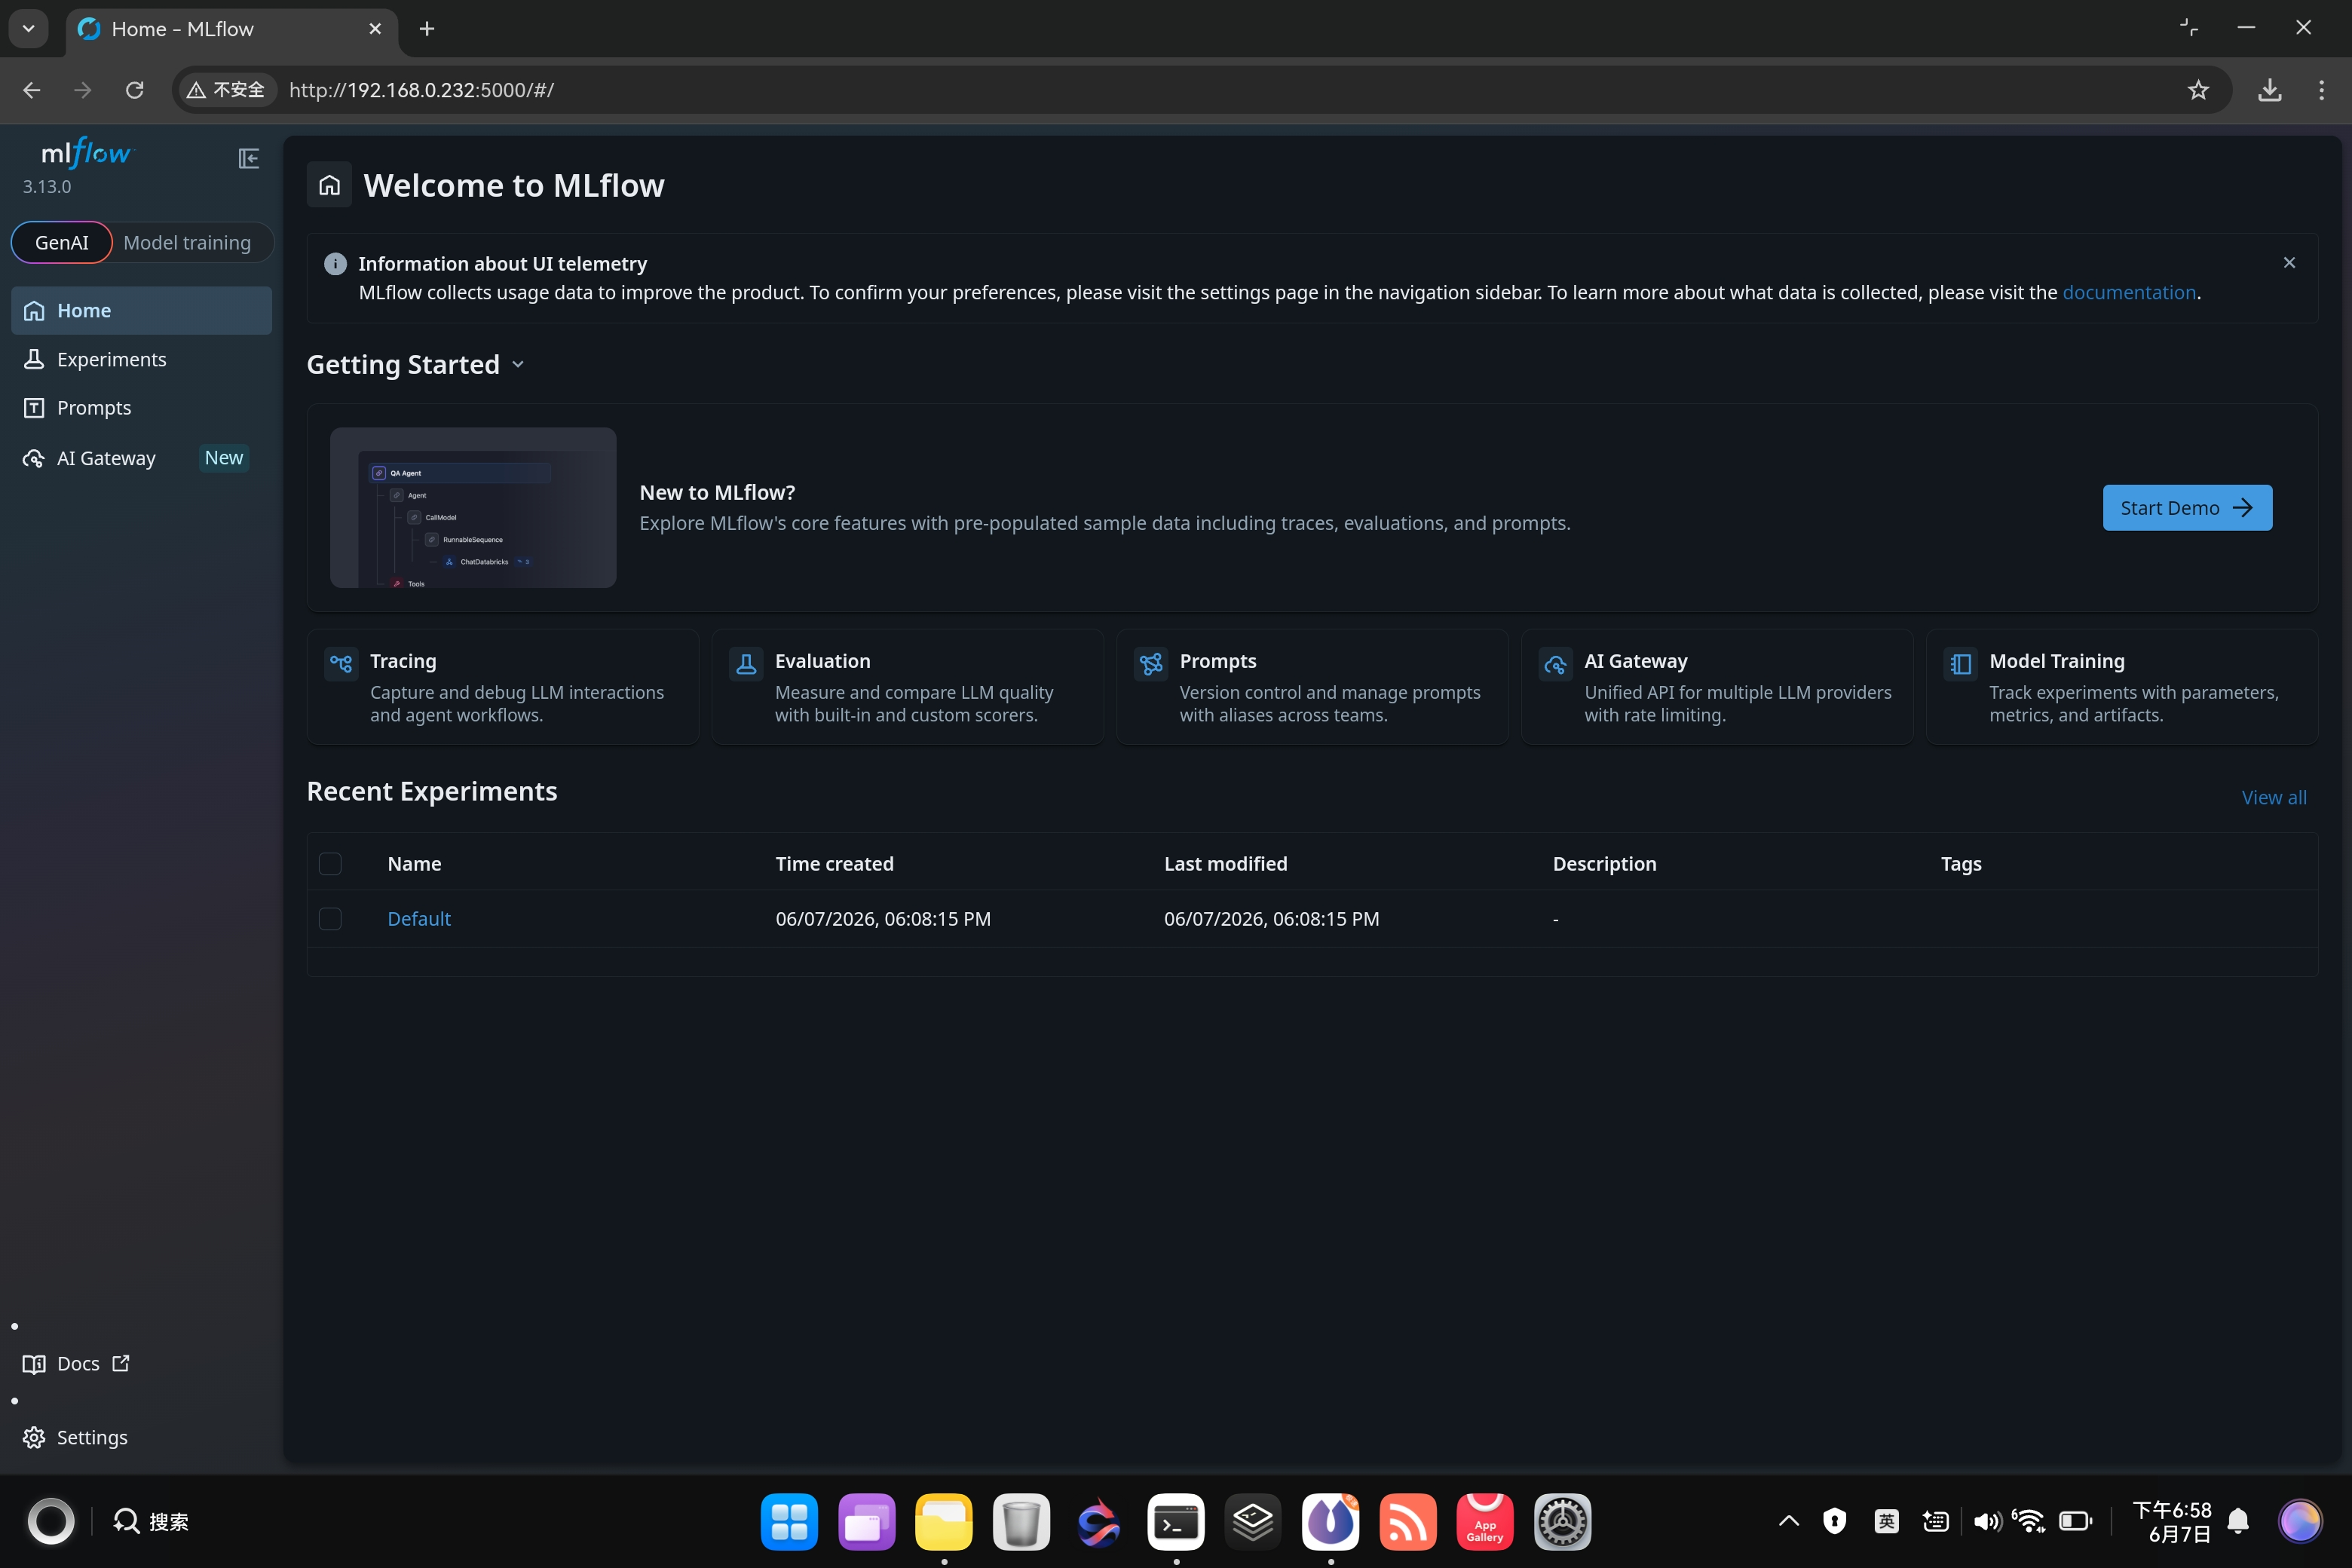

In [6]:
from IPython.display import Image

Image(filename='00-mlflow-mindspore-mlflow-homepage.jpg')

## Loading and preprocessing the Fashion MNIST dataset

The [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset serves as a quick sanity check that our model training pipeline is working correctly and that our neural network is able to learn features. The dataset is already mirrored on my website so let's download and unpack it from there.

In [7]:
import os

dataset_dir = 'data/fashion/'
os.makedirs(dataset_dir, exist_ok=True)

In [8]:
import gzip
import urllib.request

prefix_url = 'https://donaldsebleung.com/assets/datasets/fashion-mnist'
X_train_url = f'{prefix_url}/train-images-idx3-ubyte.gz'
y_train_url = f'{prefix_url}/train-labels-idx1-ubyte.gz'
X_test_url = f'{prefix_url}/t10k-images-idx3-ubyte.gz'
y_test_url = f'{prefix_url}/t10k-labels-idx1-ubyte.gz'

X_train_path = os.path.join(dataset_dir, 'train-images-idx3-ubyte')
y_train_path = os.path.join(dataset_dir, 'train-labels-idx1-ubyte')
X_test_path = os.path.join(dataset_dir, 't10k-images-idx3-ubyte')
y_test_path = os.path.join(dataset_dir, 't10k-labels-idx1-ubyte')

with urllib.request.urlopen(X_train_url) as response:
    with open(X_train_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

with urllib.request.urlopen(y_train_url) as response:
    with open(y_train_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

with urllib.request.urlopen(X_test_url) as response:
    with open(X_test_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

with urllib.request.urlopen(y_test_url) as response:
    with open(y_test_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

As usual, let's load our training and validation sets with `mindspore.dataset.FashionMnistDataset`.

In [9]:
import mindspore.dataset as ds

train_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='train', shuffle=True)
test_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='test', shuffle=True)

Apply the usual transformations to our images and labels respectively. For each image, we:

1. Resize each image to $28 \times 28$ pixels
1. Rescale each grayscale pixel by a factor of $\frac{1}{255}$ to ensure pixel values lie within the range $[0, 1]$
1. Reorder the dimensions from NHWC to NCHW format

For each label, we:

1. Apply one-hot encoding to our class labels

Additionally, we cast the values to FP16 to avoid compatibility issues with FP32 matrix multiplication on the Ascend 310B NPU.

In [10]:
import mindspore.dataset.vision as vision
import mindspore.dataset.transforms as transforms
from mindspore import dtype as mstype

def transform_ds(dataset):
    image_transforms = [
        vision.Resize(size=(28, 28)),
        vision.Rescale(rescale=1/255, shift=0),
        vision.HWC2CHW(),
        transforms.TypeCast(data_type=mstype.float16)
    ]
    label_transforms = [
        transforms.OneHot(num_classes=10),
        transforms.TypeCast(data_type=mstype.float16)
    ]
    dataset = dataset.map(operations=image_transforms, input_columns='image')
    dataset = dataset.map(operations=label_transforms, input_columns='label')
    dataset = dataset.batch(batch_size=512, drop_remainder=False)
    return dataset

train_ds = transform_ds(dataset=train_ds)
test_ds = transform_ds(dataset=test_ds)

## Defining our neural network

To keep things simple and focus on how MindSpore integrates with MLflow, we'll simply flatten our images and apply a fully connected \(FC\) linear layer with 10 raw output logits corresponding to our 10 output label classes.

Instead of subclassing `mindspore.nn.Cell` and defining the `construct` method manually, we can simply apply both operations \(flattening + FC\) sequentially with `mindspore.nn.SequentialCell`.

In [11]:
import mindspore.nn as nn

net = nn.SequentialCell([
    nn.Flatten(),
    nn.Dense(784, 10, dtype=mstype.float16)
])
net

SequentialCell(
  (0): Flatten()
  (1): Dense(input_channels=784, output_channels=10, has_bias=True)
)

## Connecting to our MLflow tracking server

Connecting to our MLflow tracking server is simple - pass in the URL to `mlflow.set_tracking_uri` and we're done.

In [12]:
import os

MLFLOW_TRACKING_SERVER_HOST = os.getenv('MLFLOW_TRACKING_SERVER_HOST', 'localhost')
MLFLOW_TRACKING_SERVER_PORT = os.getenv('MLFLOW_TRACKING_SERVER_PORT', '5000')
MLFLOW_TRACKING_SERVER_URL = f'http://{MLFLOW_TRACKING_SERVER_HOST}:{MLFLOW_TRACKING_SERVER_PORT}'
MLFLOW_TRACKING_SERVER_URL

'http://localhost:5000'

In [13]:
import mlflow

mlflow.set_tracking_uri(MLFLOW_TRACKING_SERVER_URL)

## Creating our first MLflow experiment

`mlflow.set_experiment` creates a new experiment with the given name or reuses an existing experiment with the same name if it already exists. It returns an `Experiment` object whose internal ID is available via the `experiment_id` property.

In [14]:
experiment_name = 'fashion-mnist-linear'
experiment = mlflow.set_experiment(experiment_name=experiment_name)
print(f'Created MLflow experiment with name {experiment_name} and ID {experiment.experiment_id}')

Created MLflow experiment with name fashion-mnist-linear and ID 1


Our newly created experiment appears on the homepage of our MLflow tracking server under "Recent Experiments".

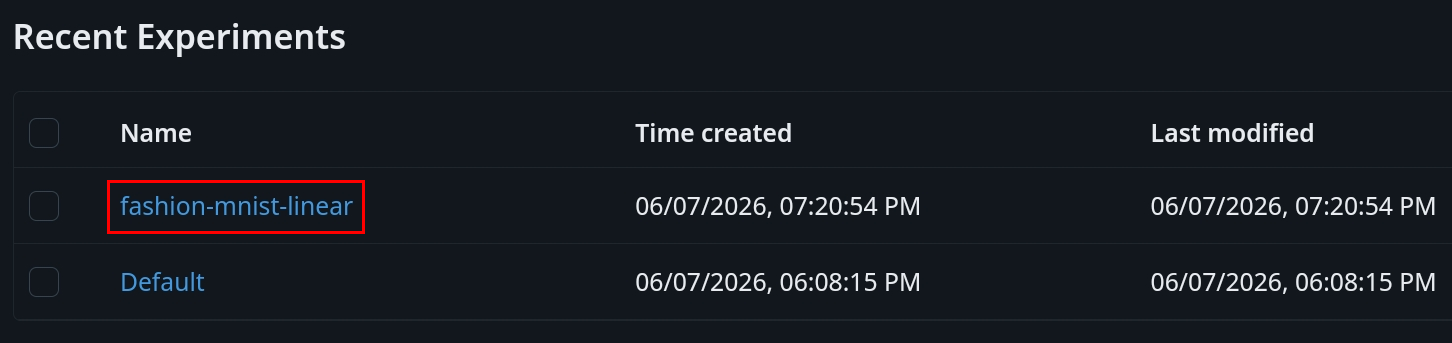

In [15]:
Image(filename='01-mlflow-mindspore-new-experiment.png')

## Defining our loss function and optimization algorithm

Let's use the standard activation + loss function and optimization algorithm for image classification problems.

1. Activation + loss function: combined softmax cross-entropy loss using the log-sum-exp trick
1. Optimization algorithm: minibatch stochaistic gradient descent \(SGD\) with a learning rate of `0.01`. Common values for the learning rate typically lie within the range `1e-2` to `1e-4`

In [16]:
loss_fn = nn.SoftmaxCrossEntropyWithLogits(reduction='mean')
loss_fn

SoftmaxCrossEntropyWithLogits()

In [17]:
optimizer = nn.SGD(params=net.trainable_params(), learning_rate=0.01)
optimizer

SGD()

## Abstracting the training loop with the MindSpore Model API

In [18]:
from mindspore.train import Model

model = Model(network=net,
              loss_fn=loss_fn,
              optimizer=optimizer,
              metrics={'accuracy', 'loss'})
model

In [19]:
from mindspore.train import LossMonitor

callbacks = [LossMonitor(per_print_times=10)]
callbacks

In [20]:
epochs = 10

## Logging MLflow run metrics and hyperparameters with custom callbacks

In [21]:
import datetime
import mindspore.ops as ops
import onnx
from mindspore.train import Callback

class MLflowFashionMNISTCallback(Callback):    
    def __init__(self, net, valid_dataset, learning_rate=0.01, version=1):
        super().__init__()
        self.net = net
        self.valid_dataset = valid_dataset
        self.learning_rate = learning_rate
        self.version = version
        
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        run_name = f"{timestamp}-lr_{self.learning_rate}"
        self.run = mlflow.start_run(run_name=run_name)
        
        hyperparameters = {
            "learning_rate": self.learning_rate,
            "weight_decay": 0,
            "momentum": 0,
            "loss": "softmax_cross_entropy",
            "optimizer": "sgd",
            "batch_size": 512,
            "network_type": "linear",
            "epochs": 10
        }
        mlflow.log_params(hyperparameters)
    
    def on_train_begin(self, run_context):
        pass
    
    def on_train_step_end(self, run_context):
        cb_params = run_context.original_args()
        current_loss = cb_params.net_outputs.asnumpy().mean()
        mlflow.log_metric("train_loss", current_loss, step=cb_params.cur_step_num)
    
    def on_train_epoch_end(self, run_context):
        cb_params = run_context.original_args()
    
        if hasattr(cb_params, 'eval_results') and cb_params.eval_results:
            val_loss = cb_params.eval_results.get('loss', 0.0)
            val_accuracy = cb_params.eval_results.get('accuracy', 0.0)
            mlflow.log_metric('val_loss', val_loss, step=cb_params.cur_epoch_num)
            mlflow.log_metric('val_accuracy', val_accuracy, step=cb_params.cur_epoch_num)
    
    def on_train_end(self, run_context):
        onnx_path = f"fashion-mnist-linear-{self.version:02d}.onnx"
        dummy_input = ops.randn((1, 1, 28, 28), dtype=mstype.float16)
        mindspore.onnx.export(self.net,
                              dummy_input,
                              file_name=onnx_path,
                              input_names=['image'],
                              output_names=['label'])
        
        onnx_model = onnx.load(onnx_path)
        mlflow.onnx.log_model(
            onnx_model=onnx_model,
            name=f"fashion-mnist-linear-{self.version:02d}"
        )
        
        mlflow.end_run()
    
    def __del__(self):
        if hasattr(self, 'run') and self.run is not None:
            try:
                mlflow.end_run()
            except:
                pass

In [22]:
callbacks.append(MLflowFashionMNISTCallback(net=net, valid_dataset=test_ds))
callbacks

In [23]:
model.fit(epoch=epochs,
          train_dataset=train_ds,
          valid_dataset=test_ds,
          callbacks=callbacks,
          dataset_sink_mode=False)

/usr/local/Ascend/cann-9.0.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:179: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/c

path string is NULLpath string is NULL.epoch: 1 step: 10, loss is 2.091796875
epoch: 1 step: 20, loss is 1.939453125
epoch: 1 step: 30, loss is 1.8232421875
epoch: 1 step: 40, loss is 1.689453125
epoch: 1 step: 50, loss is 1.6064453125
epoch: 1 step: 60, loss is 1.541015625
epoch: 1 step: 70, loss is 1.4658203125
epoch: 1 step: 80, loss is 1.412109375
epoch: 1 step: 90, loss is 1.392578125
epoch: 1 step: 100, loss is 1.3486328125
epoch: 1 step: 110, loss is 1.310546875
Eval result: epoch 1, metrics: {'loss': 1.2708984375, 'accuracy': 0.6536}
epoch: 2 step: 2, loss is 1.2724609375
epoch: 2 step: 12, loss is 1.21484375
epoch: 2 step: 22, loss is 1.171875
epoch: 2 step: 32, loss is 1.177734375
epoch: 2 step: 42, loss is 1.142578125
epoch: 2 step: 52, loss is 1.1552734375
epoch: 2 step: 62, loss is 1.078125
epoch: 2 step: 72, loss is 1.0849609375
epoch: 2 step: 82, loss is 1.0830078125
epoch: 2 step: 92, loss is 1.099609375
epoch: 2 step: 102, loss is 1.0712890625
epoch: 2 step: 112, loss 

onnxruntime cpuid_info warning: Unknown CPU vendor. cpuinfo_vendor value: 0
2026-06-07 23:38:21.468026834 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card1": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card1/device/vendor"
2026-06-07 23:38:21.468118293 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


🏃 View run 20260607_233406-lr_0.01 at: http://localhost:5000/#/experiments/1/runs/05a1b50cf5344ef6b6024be54b5d8eac
🧪 View experiment at: http://localhost:5000/#/experiments/1


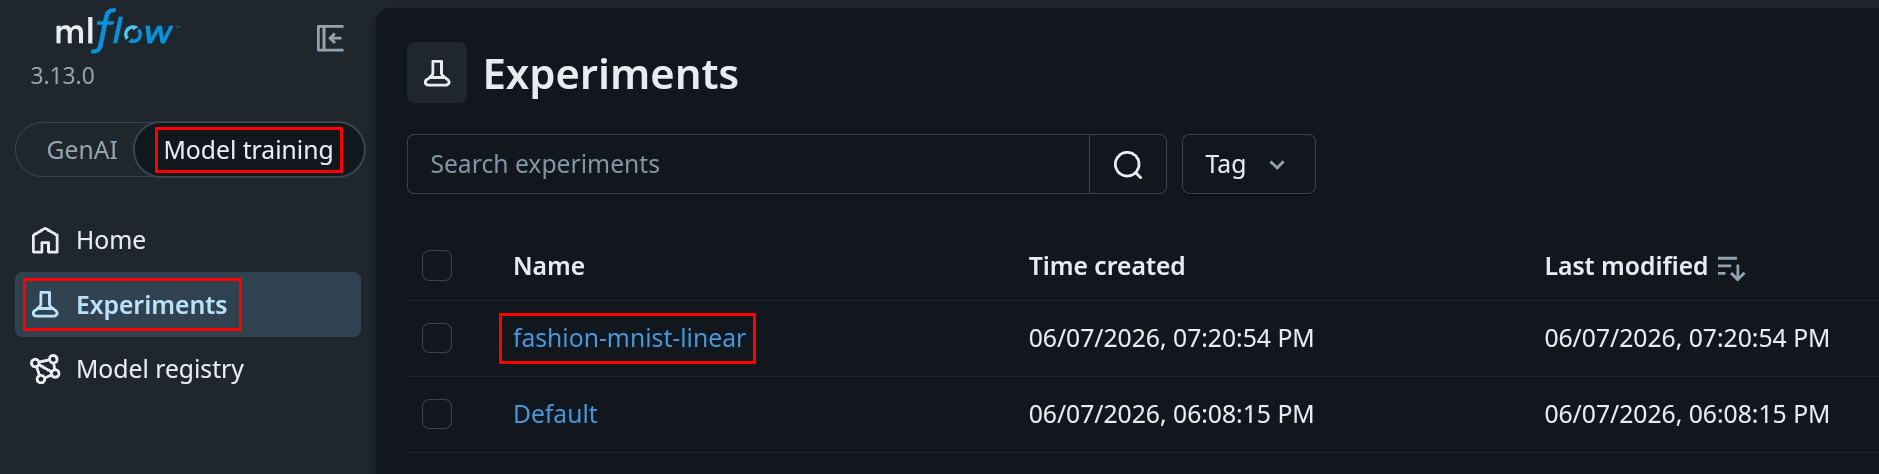

In [24]:
Image(filename='02-mlflow-mindspore-select-experiment.png')

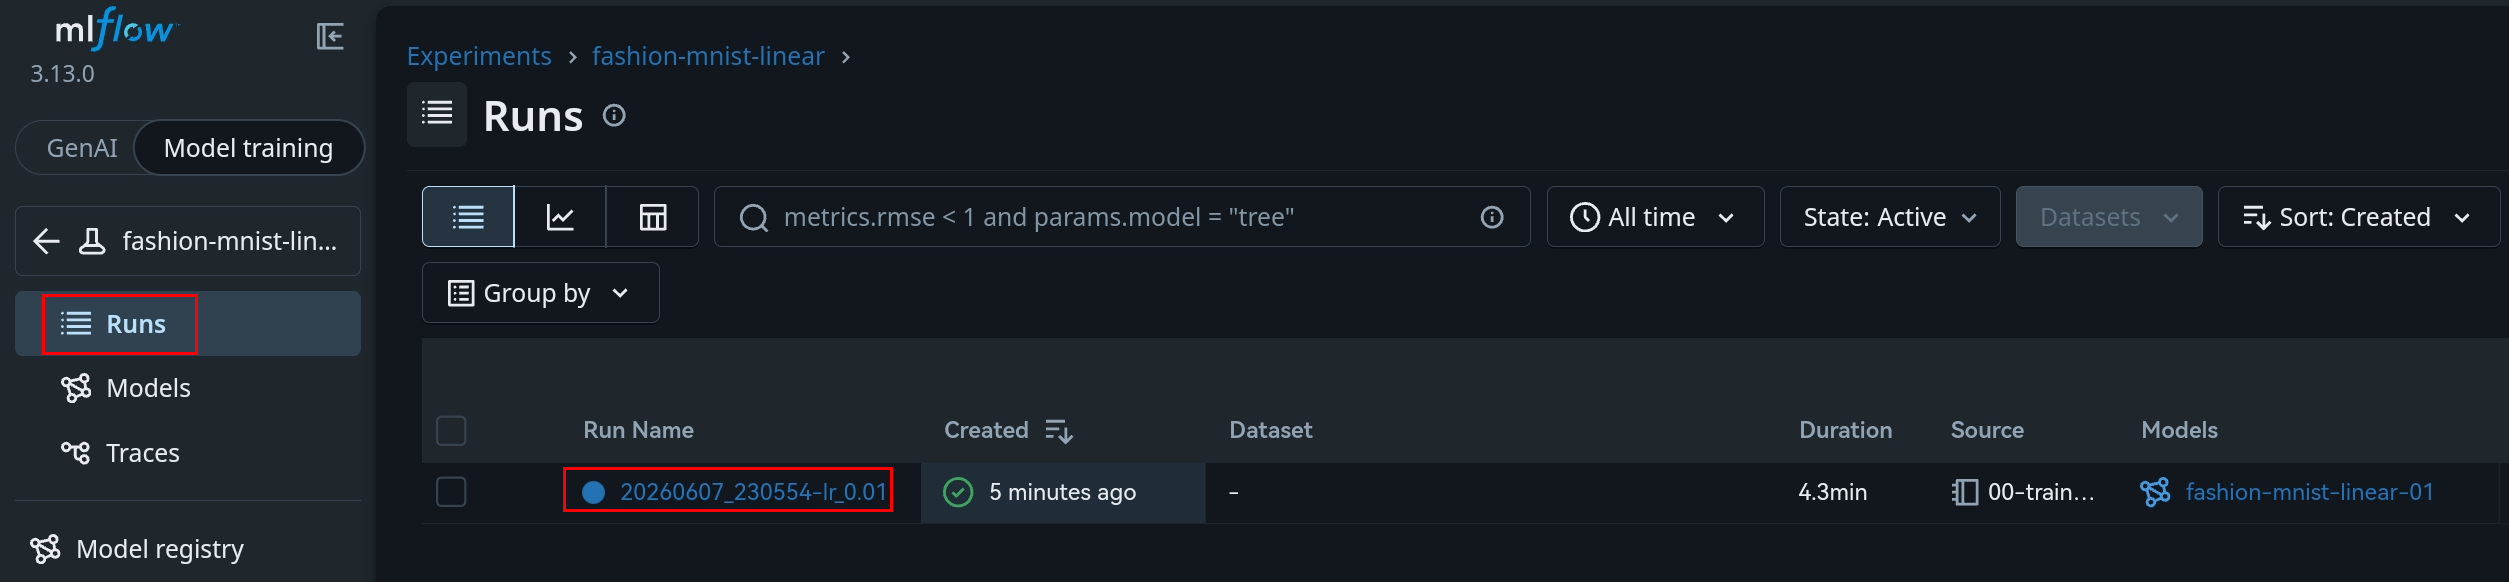

In [25]:
Image(filename='03-mlflow-mindspore-experiment-select-run.png')

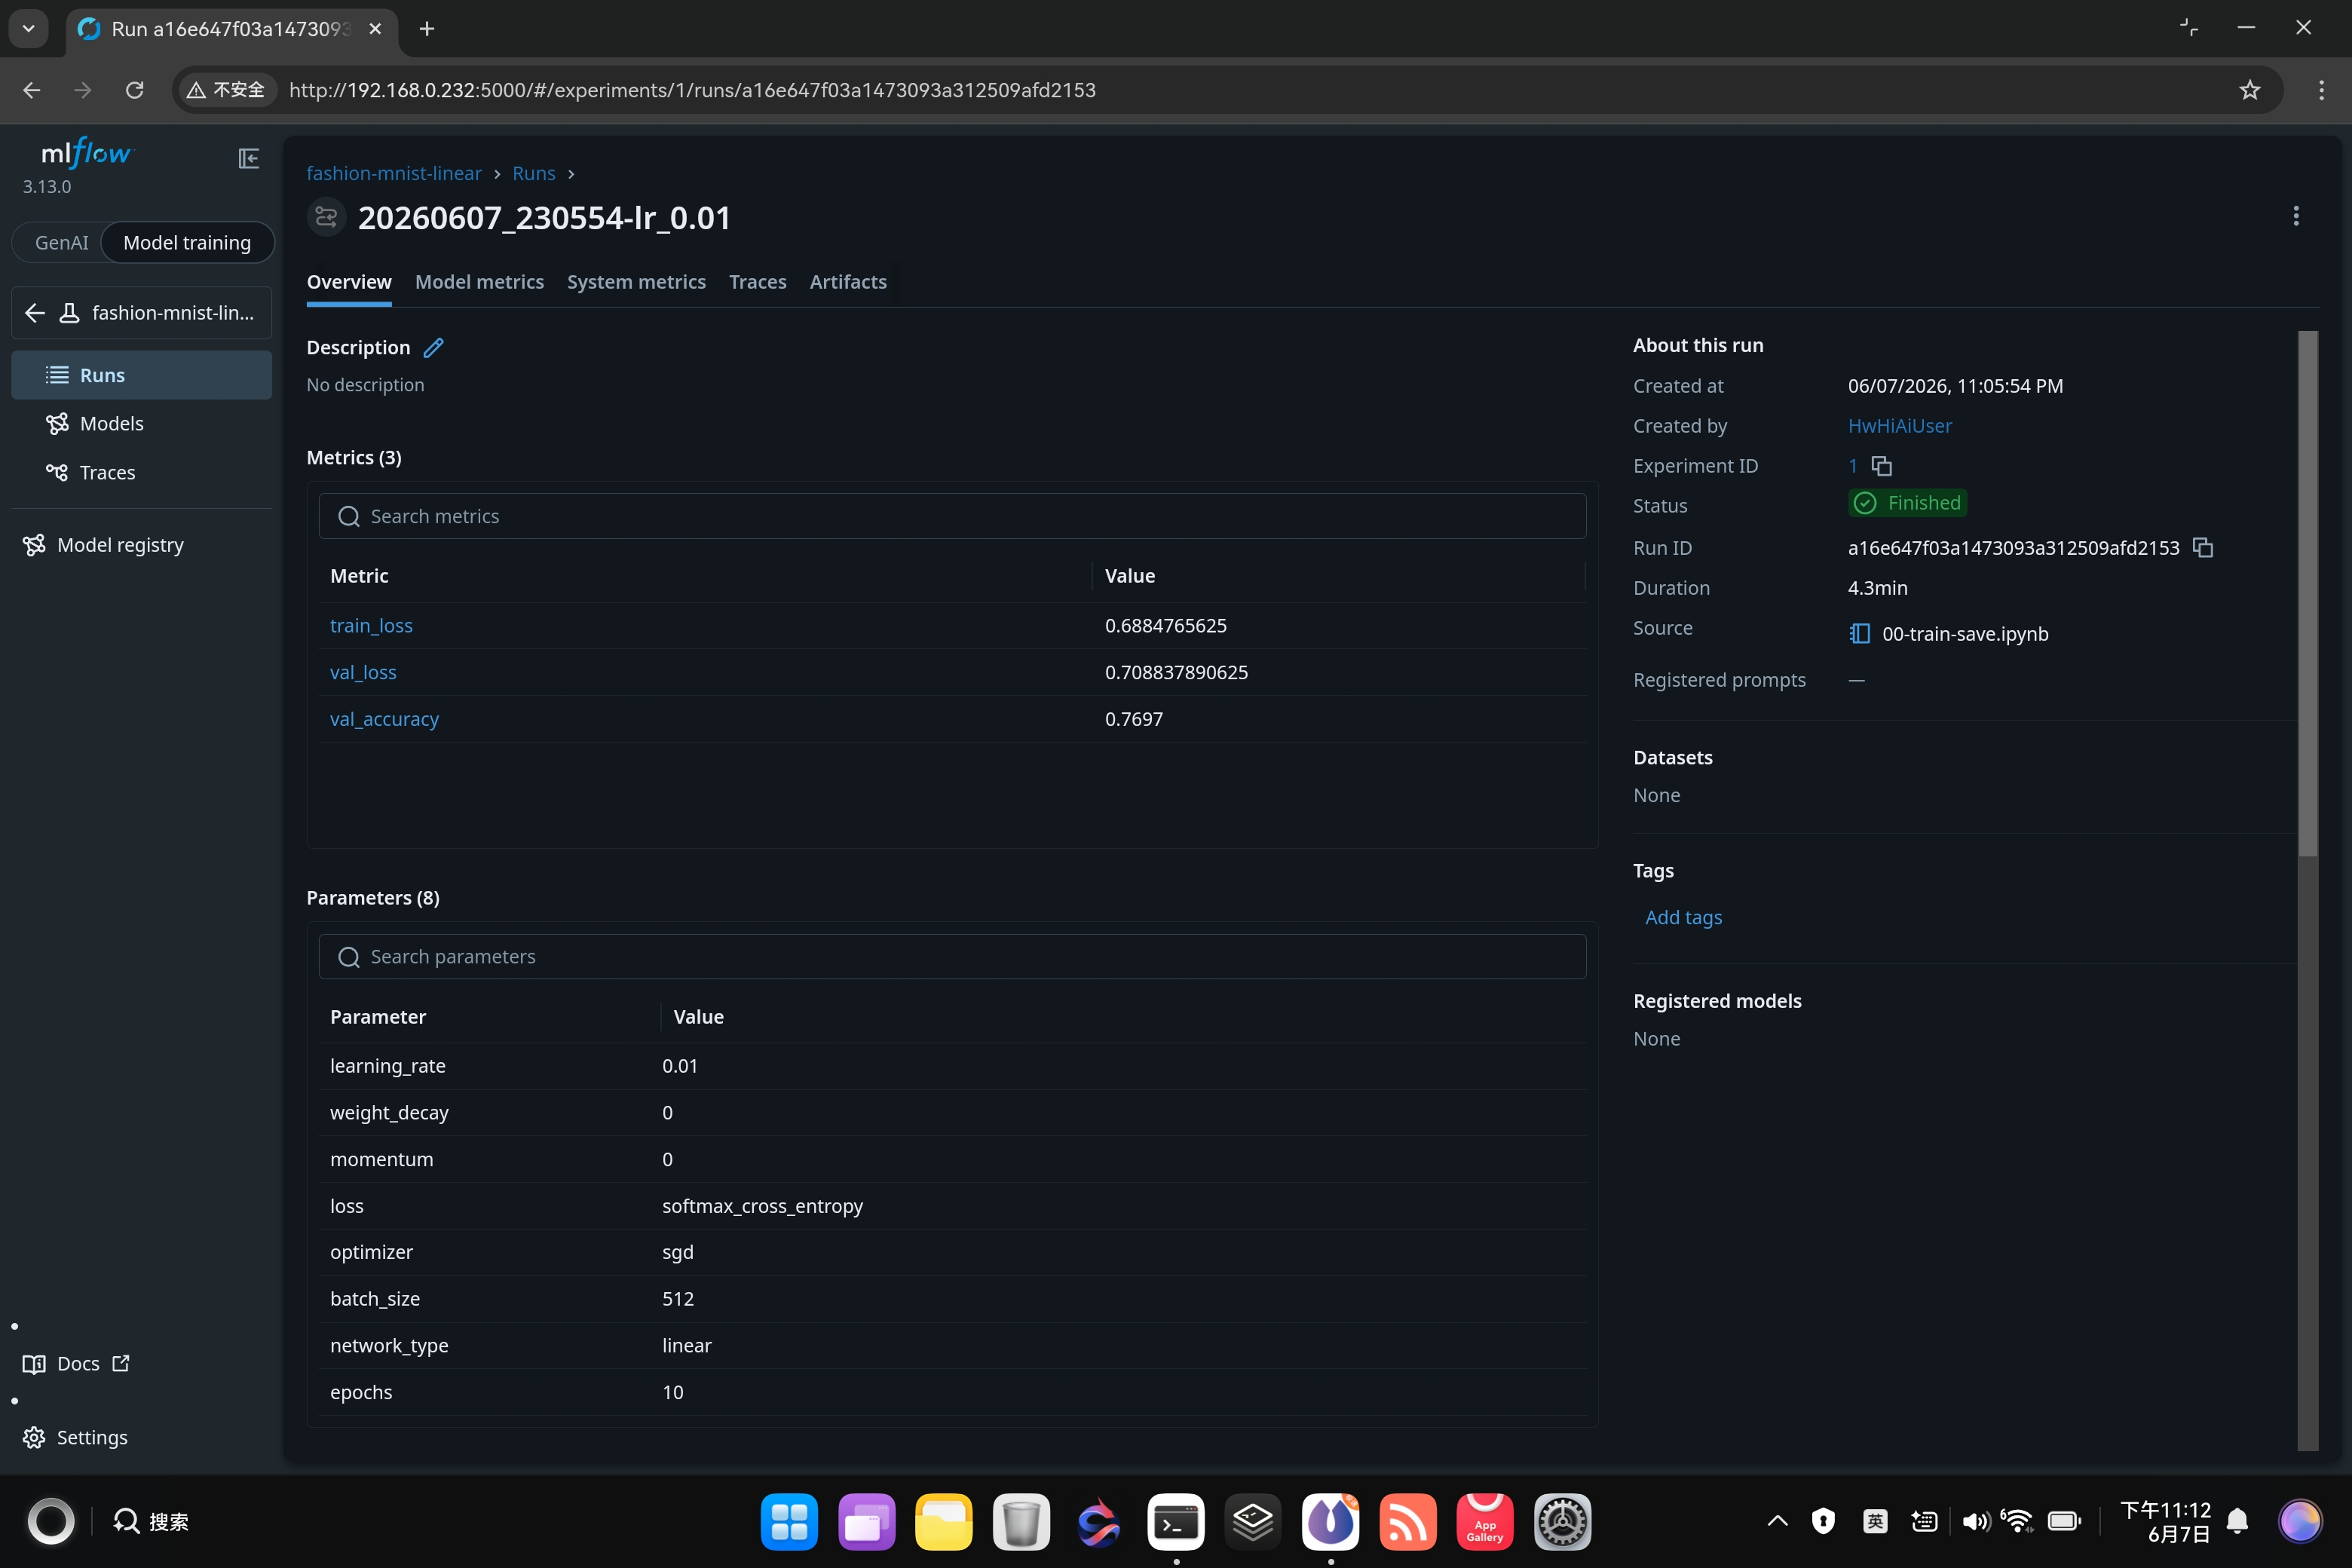

In [26]:
Image(filename='04-mlflow-mindspore-run-metrics-hyperparameters.jpg')

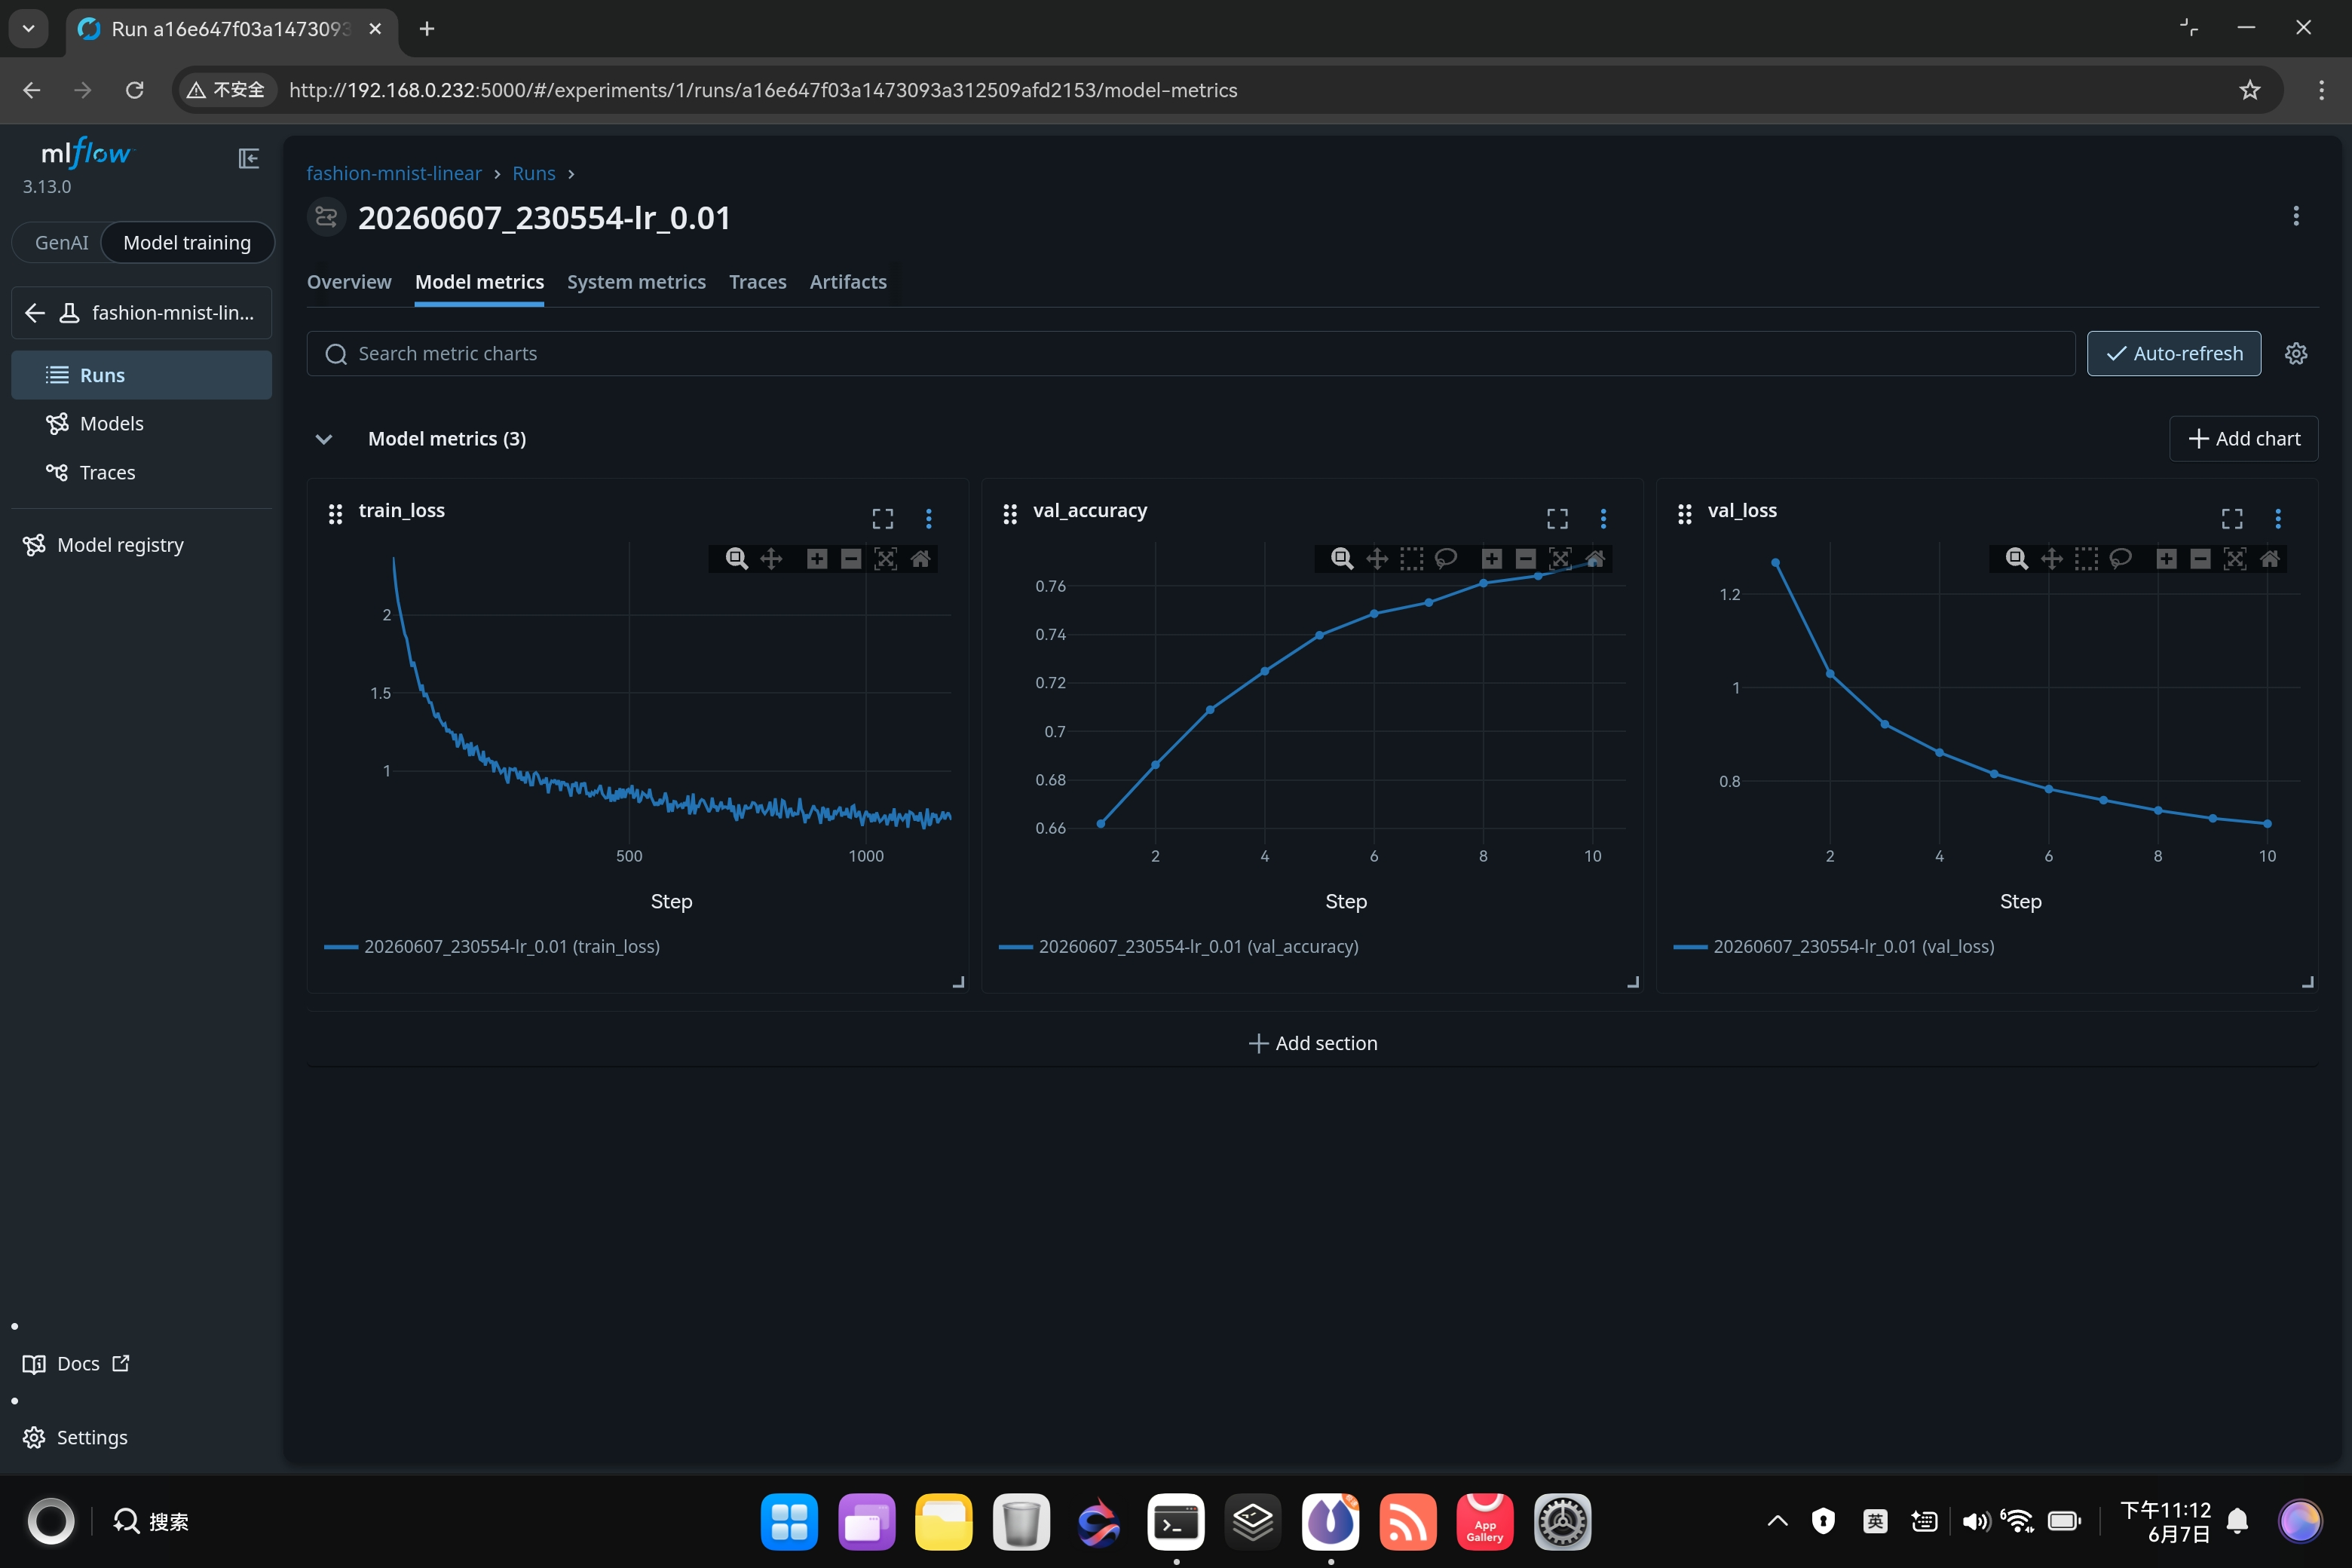

In [27]:
Image(filename='05-mlflow-mindspore-run-metrics-graphs.jpg')

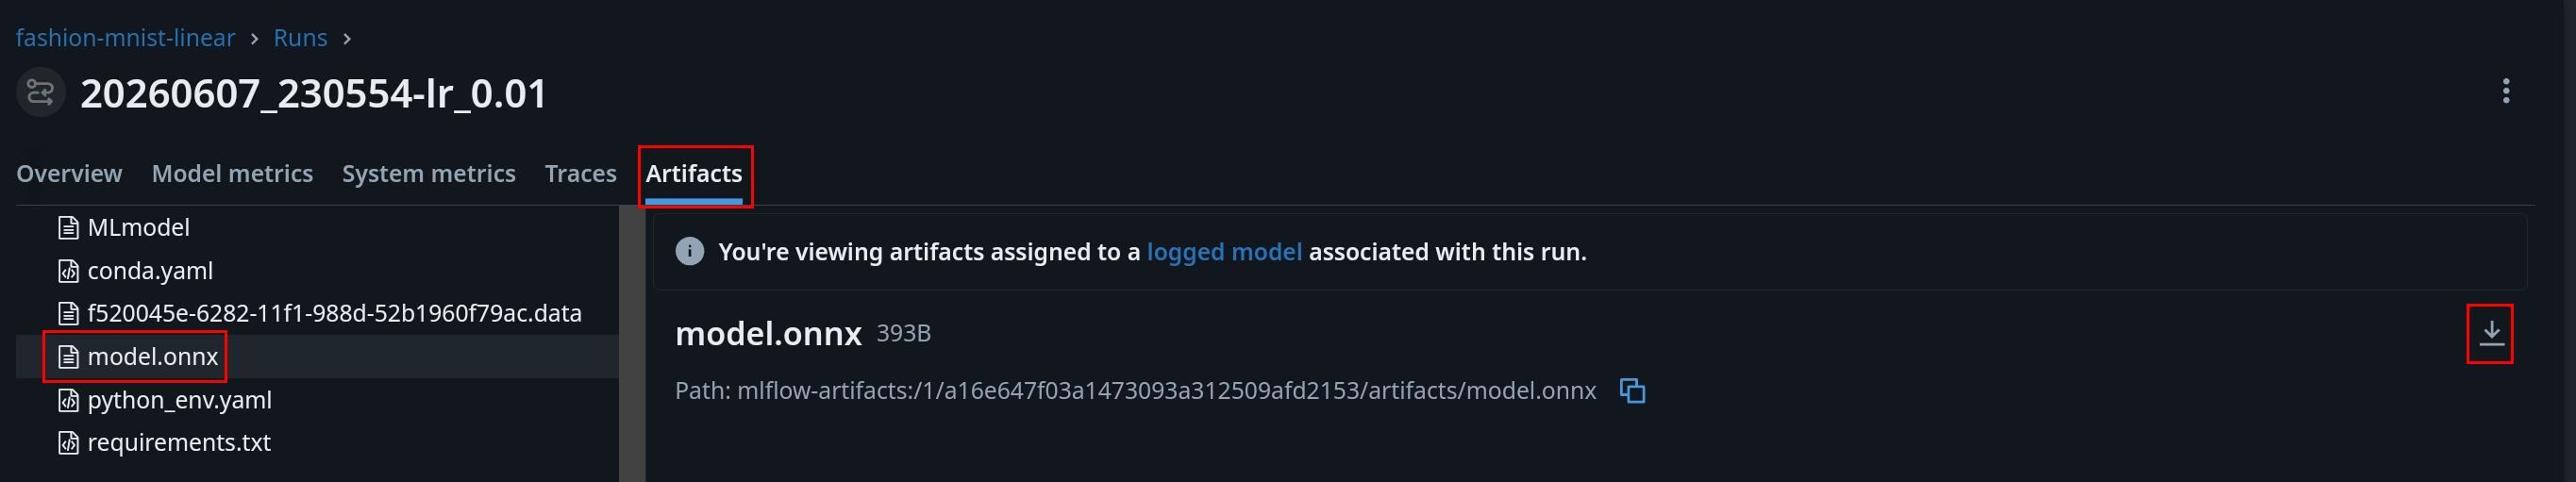

In [28]:
Image(filename='06-mlflow-mindspore-run-onnx-model.png')

## Creating a new MLflow run with different hyperparameters

In [29]:
train_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='train', shuffle=True)
test_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='test', shuffle=True)

In [30]:
train_ds = transform_ds(dataset=train_ds)
test_ds = transform_ds(dataset=test_ds)

In [31]:
net = nn.SequentialCell([
    nn.Flatten(),
    nn.Dense(784, 10, dtype=mstype.float16)
])
net

SequentialCell(
  (0): Flatten()
  (1): Dense(input_channels=784, output_channels=10, has_bias=True)
)

In [32]:
optimizer = nn.SGD(params=net.trainable_params(), learning_rate=0.1)
optimizer

SGD()

In [33]:
model = Model(network=net,
              loss_fn=loss_fn,
              optimizer=optimizer,
              metrics={'accuracy', 'loss'})
model

In [34]:
callbacks = [
    LossMonitor(per_print_times=10),
    MLflowFashionMNISTCallback(net=net, valid_dataset=test_ds, learning_rate=0.1, version=2)
]
callbacks

In [35]:
model.fit(epoch=epochs,
          train_dataset=train_ds,
          valid_dataset=test_ds,
          callbacks=callbacks,
          dataset_sink_mode=False)

epoch: 1 step: 10, loss is 1.4189453125
epoch: 1 step: 20, loss is 1.09375
epoch: 1 step: 30, loss is 0.9716796875
epoch: 1 step: 40, loss is 0.86962890625
epoch: 1 step: 50, loss is 0.81396484375
epoch: 1 step: 60, loss is 0.80810546875
epoch: 1 step: 70, loss is 0.7412109375
epoch: 1 step: 80, loss is 0.771484375
epoch: 1 step: 90, loss is 0.71142578125
epoch: 1 step: 100, loss is 0.728515625
epoch: 1 step: 110, loss is 0.693359375
Eval result: epoch 1, metrics: {'loss': 0.7176513671875, 'accuracy': 0.7601}
epoch: 2 step: 2, loss is 0.67724609375
epoch: 2 step: 12, loss is 0.6669921875
epoch: 2 step: 22, loss is 0.693359375
epoch: 2 step: 32, loss is 0.65966796875
epoch: 2 step: 42, loss is 0.66162109375
epoch: 2 step: 52, loss is 0.63330078125
epoch: 2 step: 62, loss is 0.609375
epoch: 2 step: 72, loss is 0.611328125
epoch: 2 step: 82, loss is 0.60888671875
epoch: 2 step: 92, loss is 0.5966796875
epoch: 2 step: 102, loss is 0.67724609375
epoch: 2 step: 112, loss is 0.64892578125
Eva

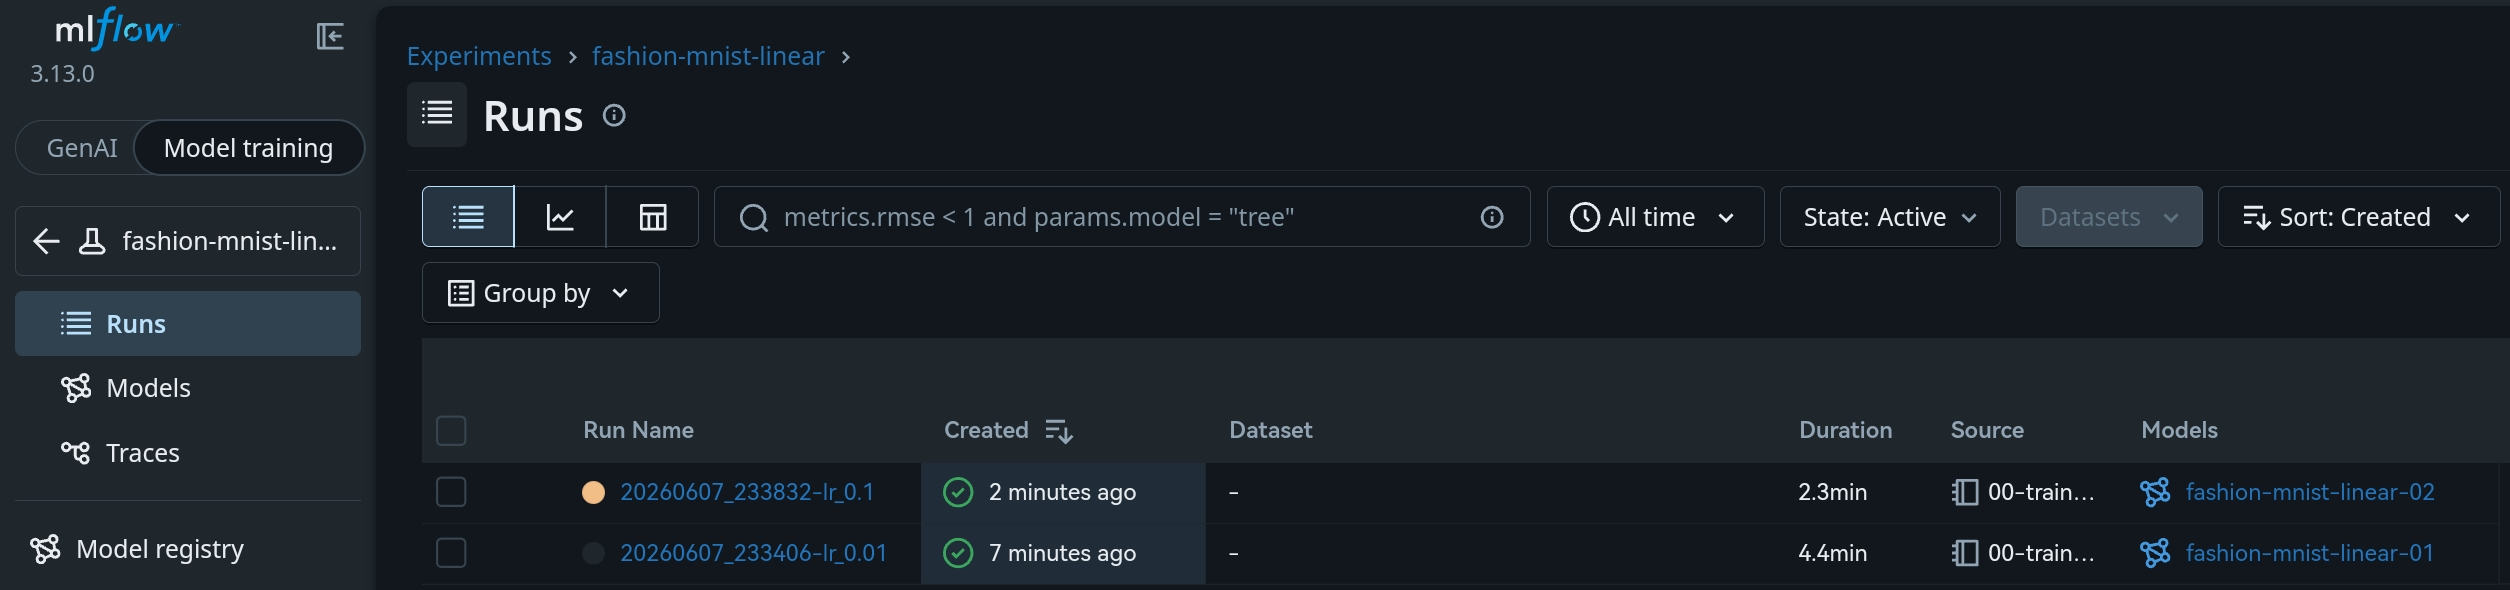

In [36]:
Image(filename='07-mlflow-mindspore-experiment-multiple-runs.jpg')

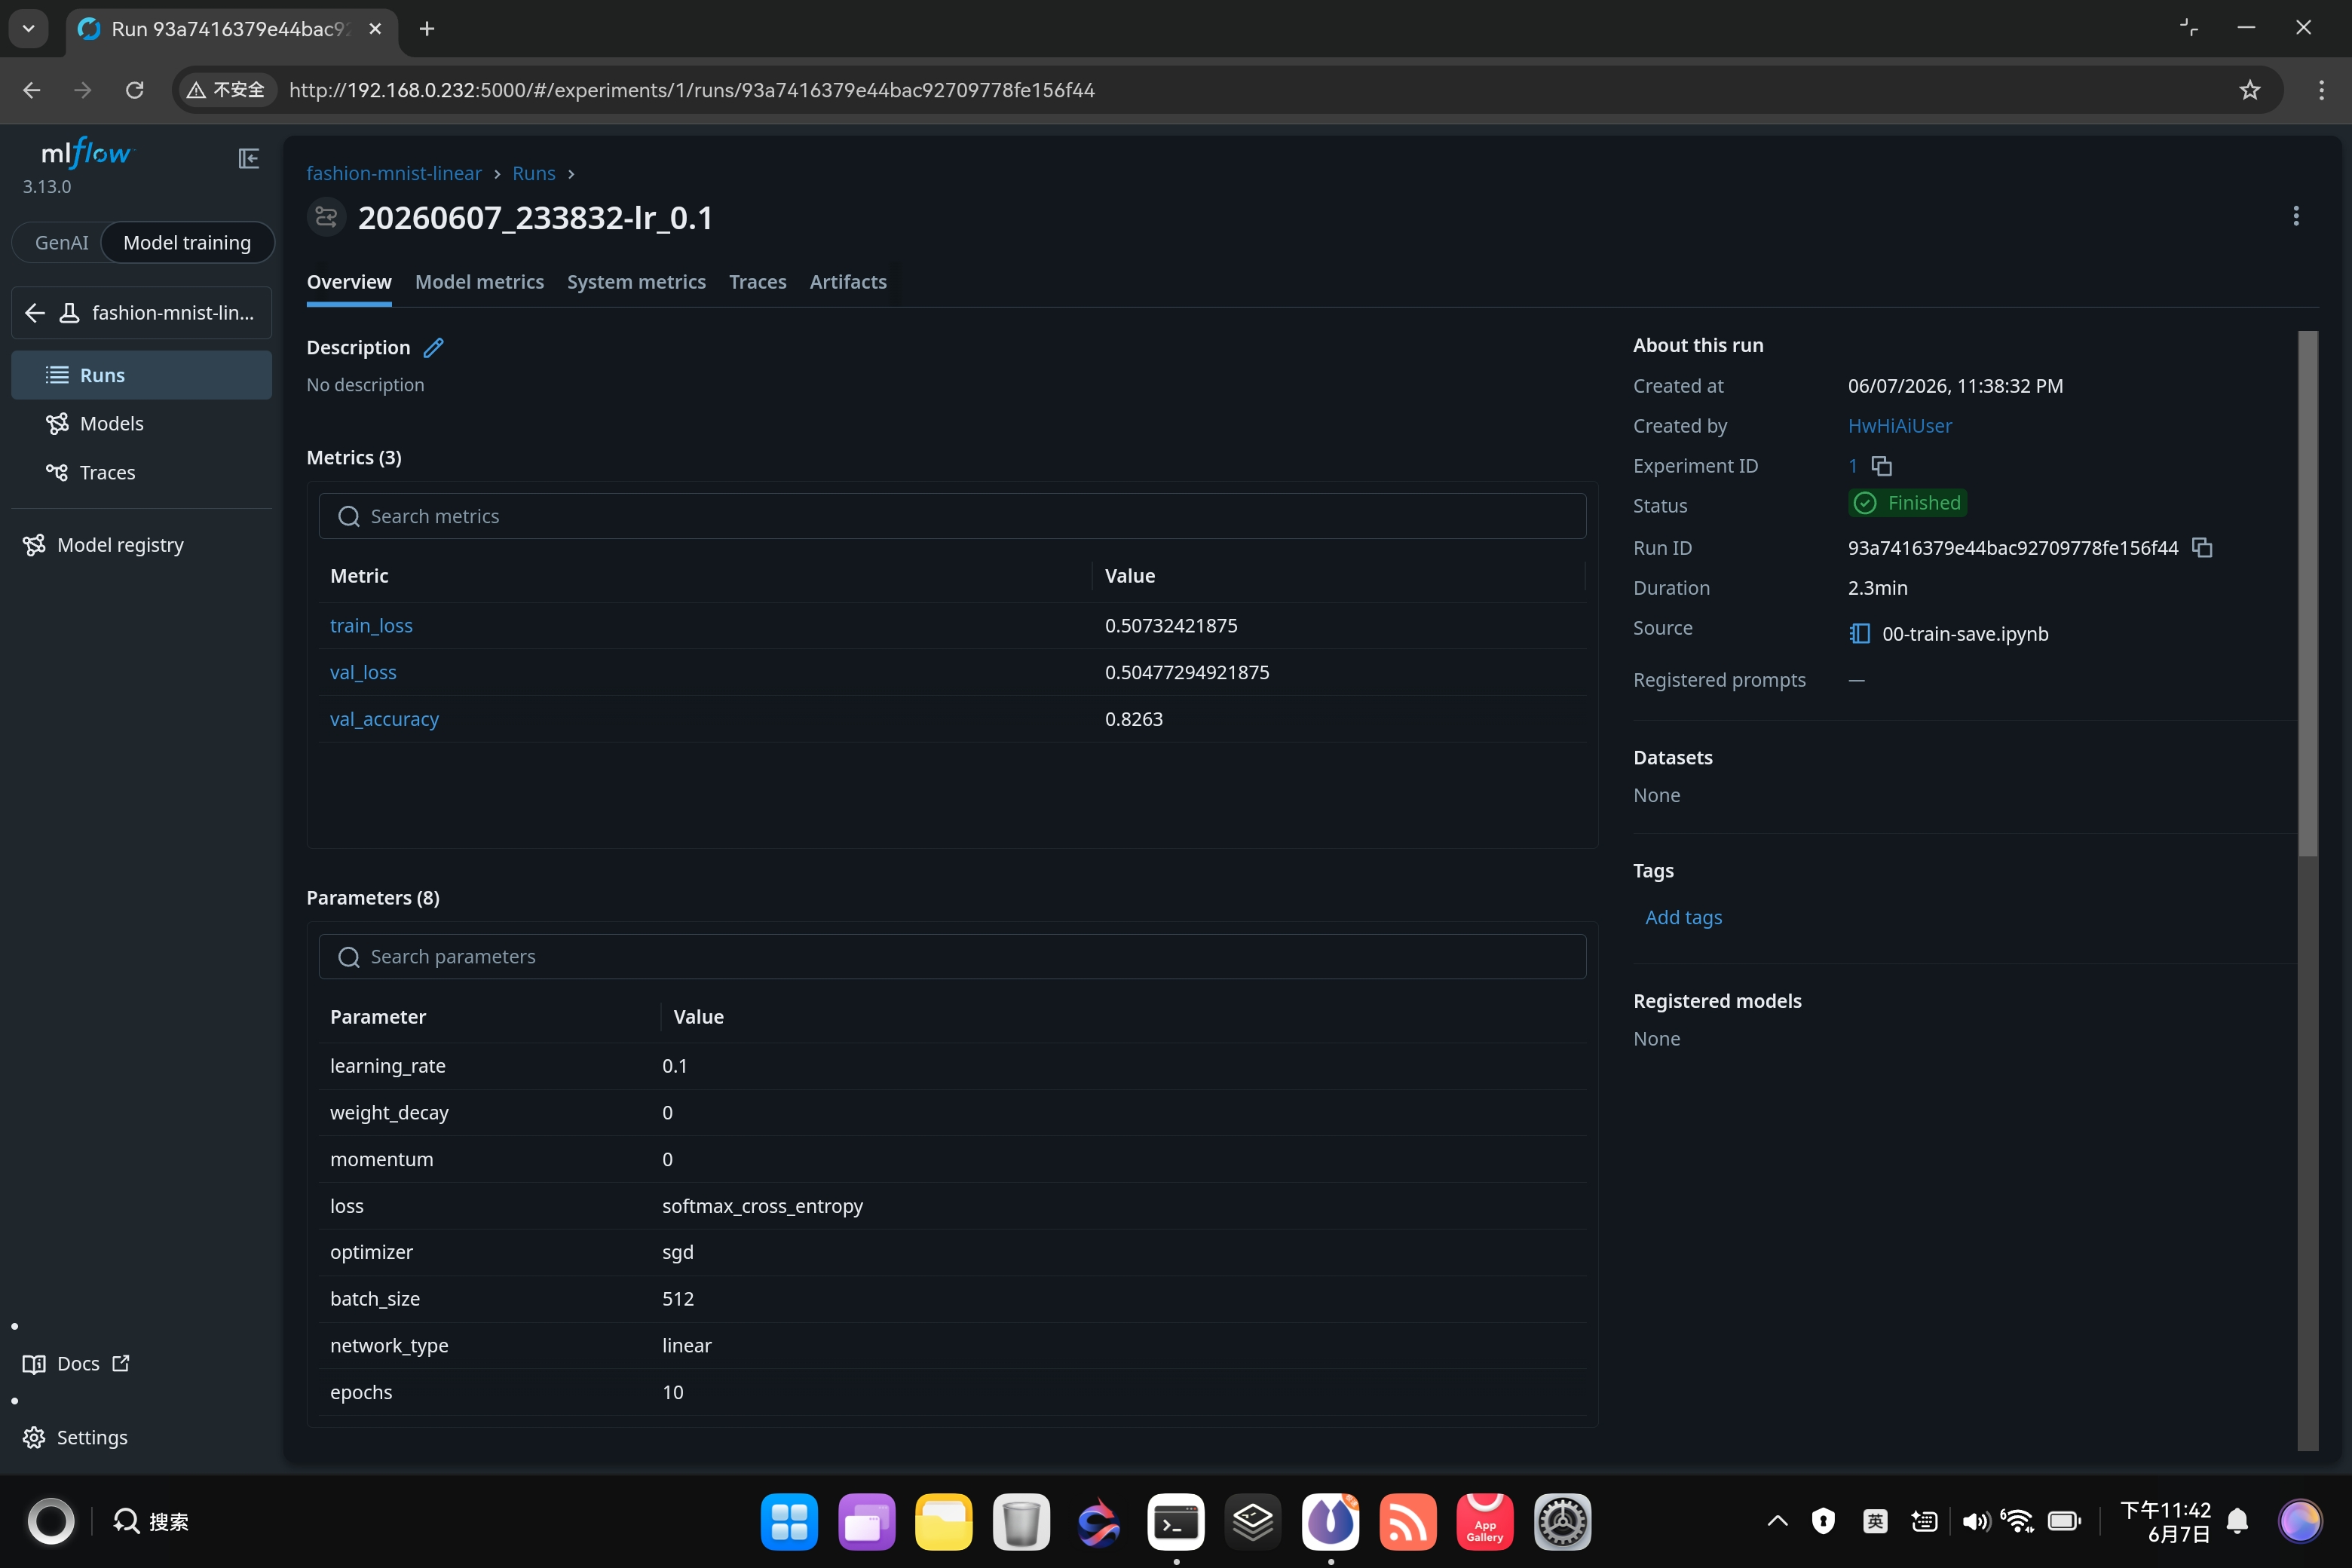

In [37]:
Image(filename='08-mlflow-mindspore-run-02-metrics-hyperparameters.jpg')

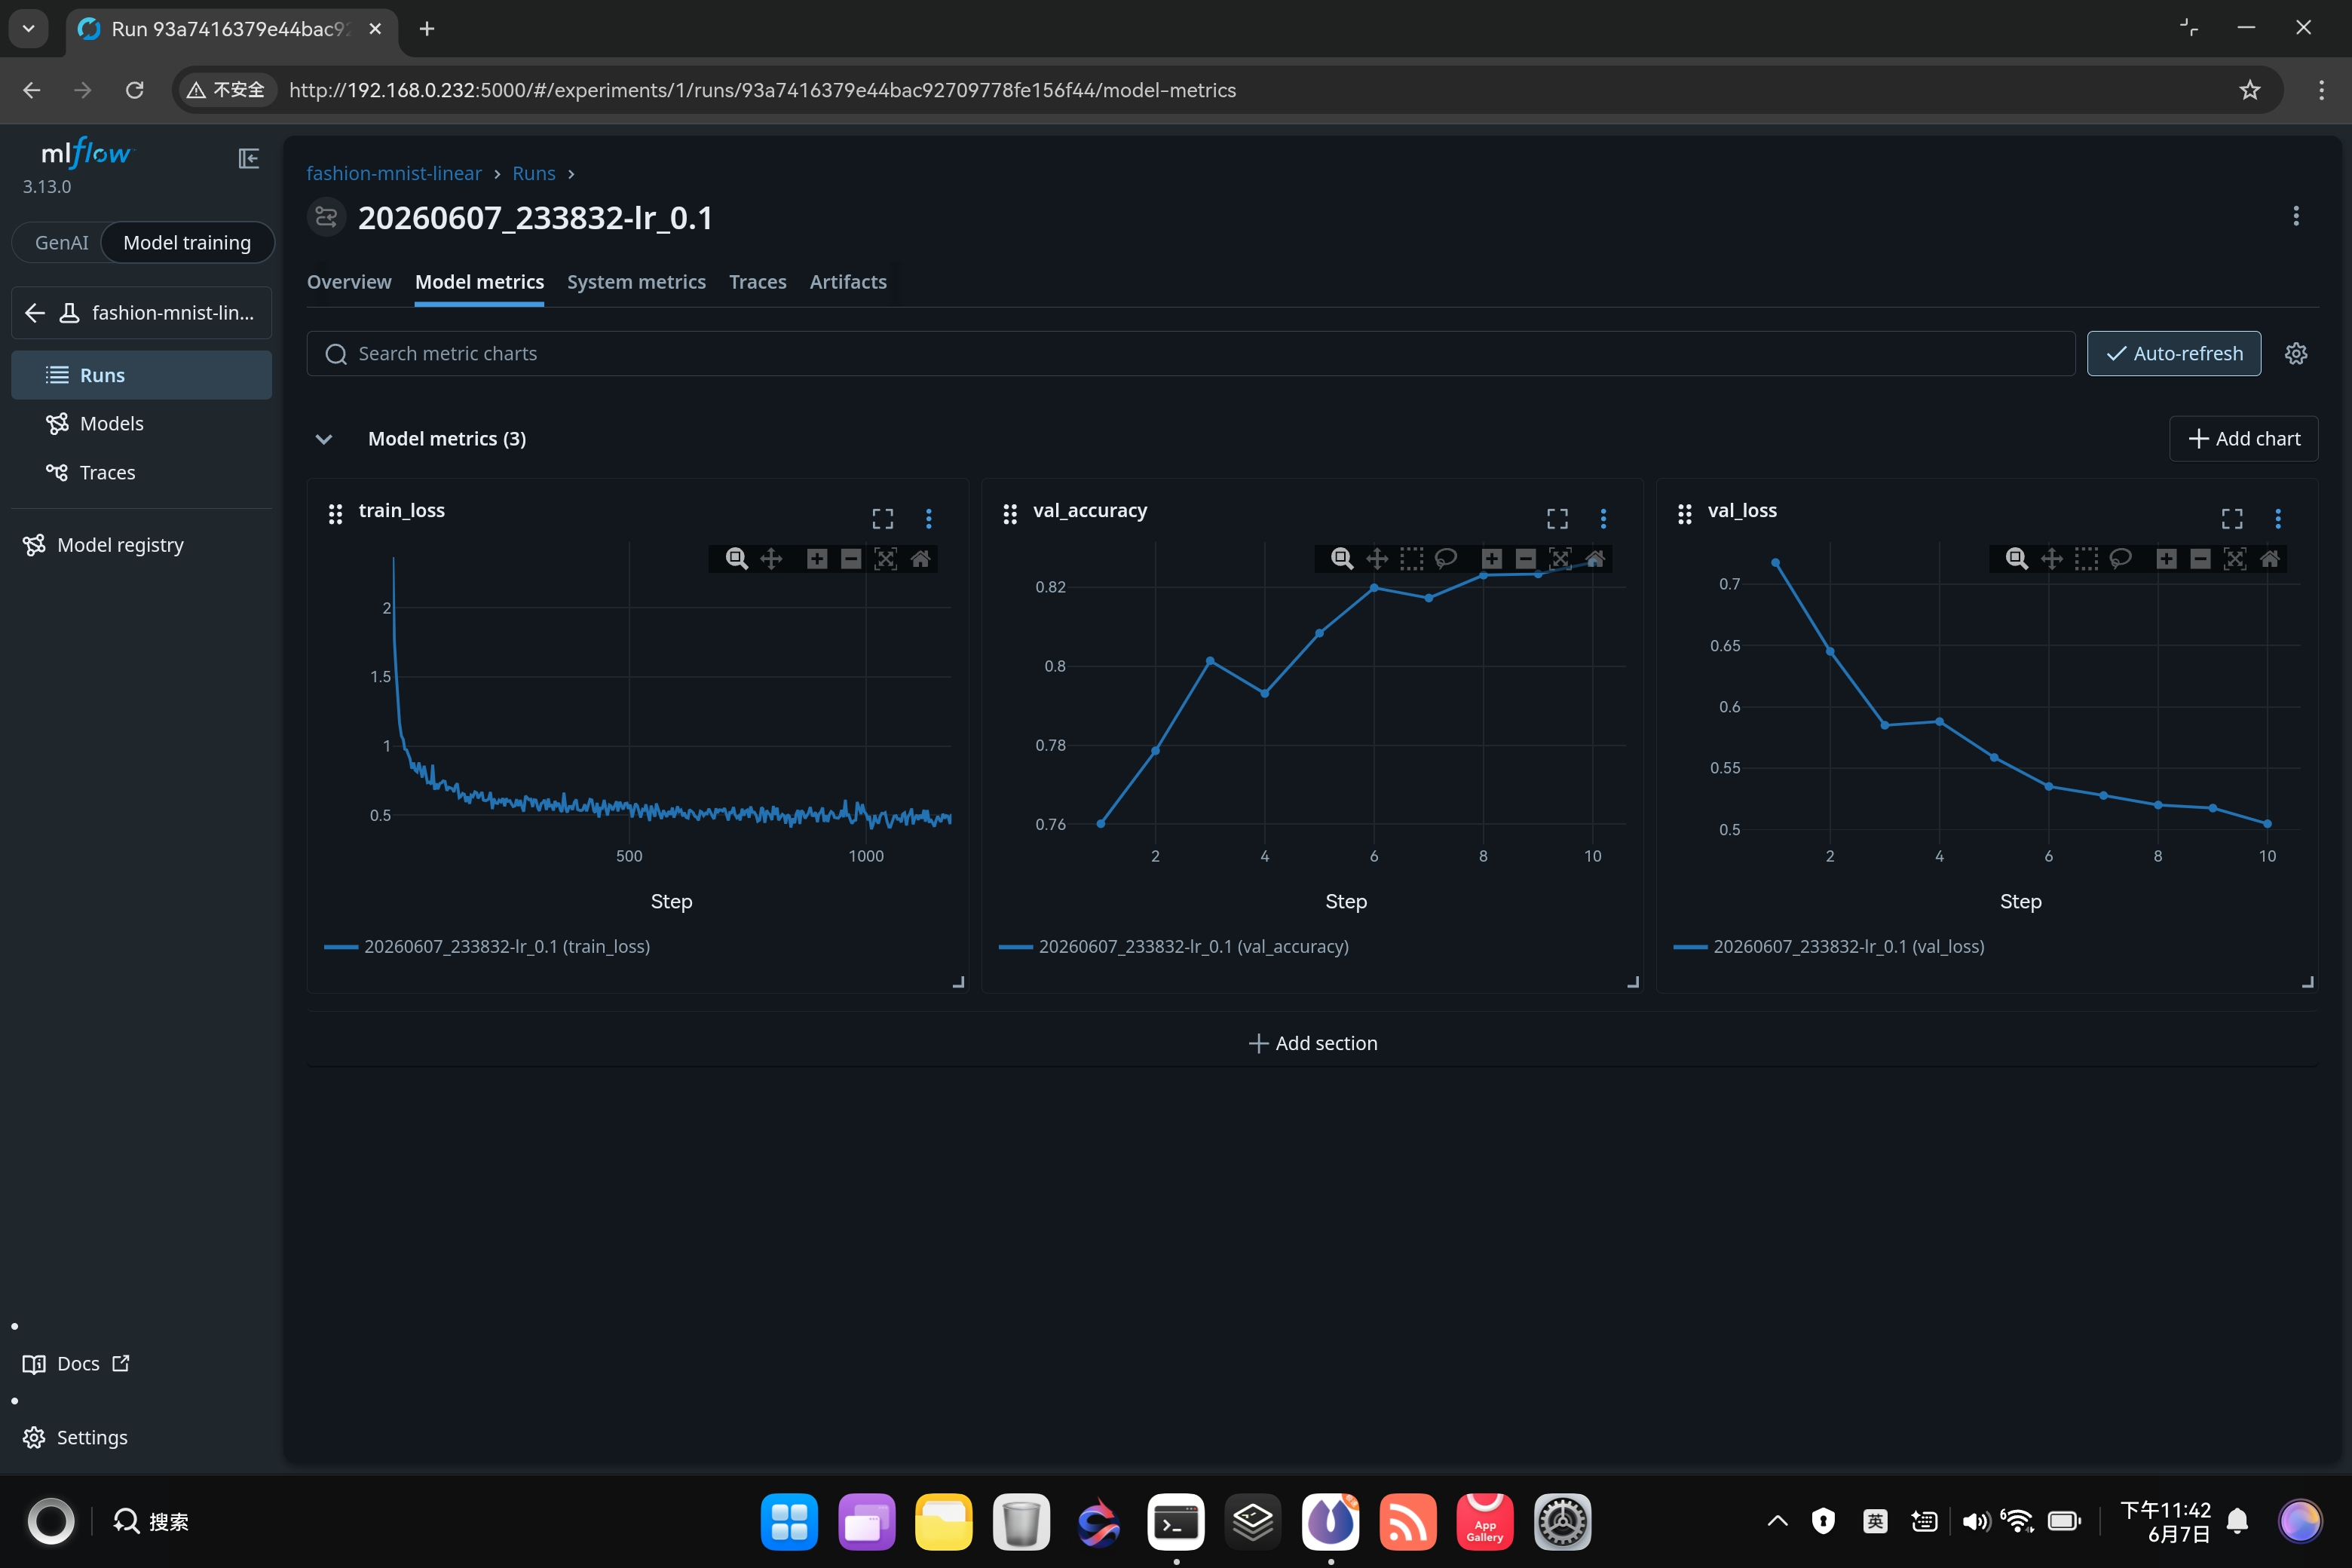

In [38]:
Image(filename='09-mlflow-mindspore-run-02-metrics-graphs.jpg')

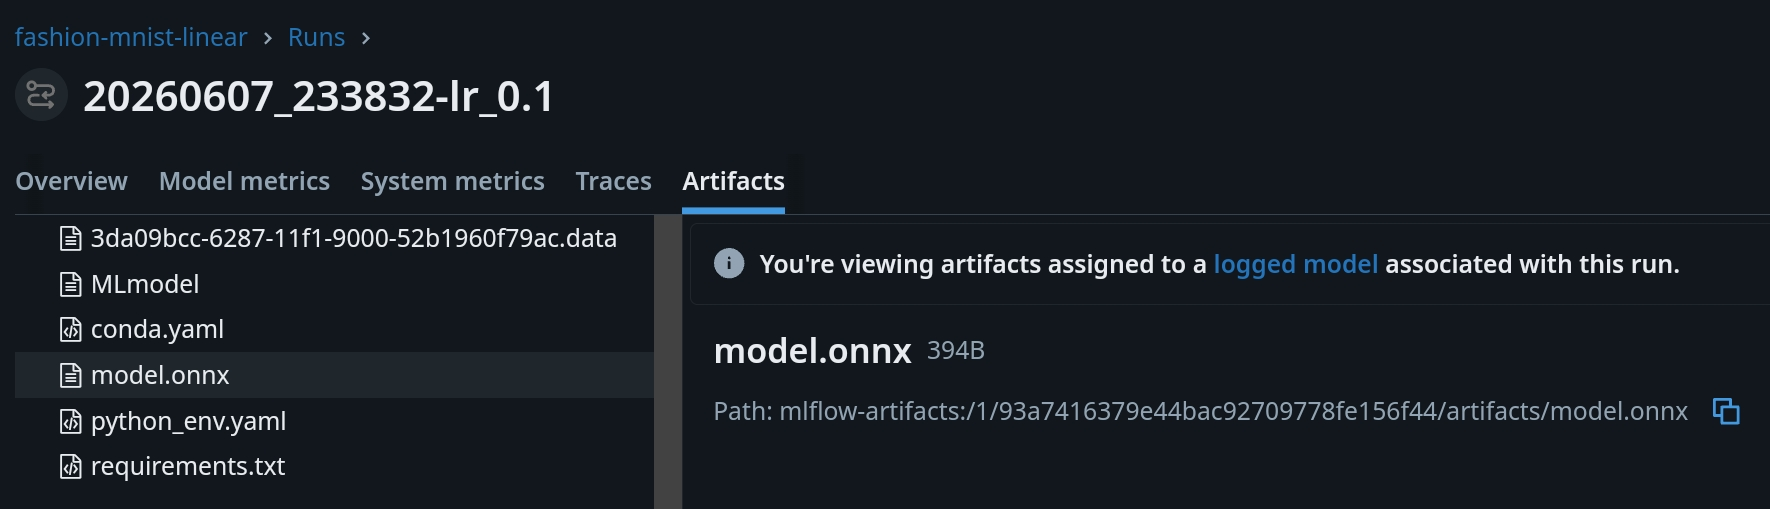

In [39]:
Image(filename='10-mlflow-mindspore-run-02-onnx-model.jpg')

## Concluding remarks and going further

TODO